# Assignment 2 — Starter Notebook

Fill in the TODO sections.


In [1]:
# Imports
import os
from pathlib import Path
import random
import time

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as T

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
def show_grid(imgs, nrow=8, folder = "gen_images", title="", cmap=None, resize_to=None):
    import math
    import torchvision
    import torch.nn.functional as F
    import matplotlib.pyplot as plt

    if len(imgs) == 0:
        return

    proc = []
    shapes = []
    for x in imgs:
        x = x.detach().cpu()
        if x.ndim == 2:
            x = x.unsqueeze(0)
        proc.append(x)
        shapes.append((int(x.shape[1]), int(x.shape[2])))

    if resize_to is None and len(set(shapes)) > 1:
        resize_to = (min(h for h, w in shapes), min(w for h, w in shapes))

    if resize_to is not None:
        th, tw = int(resize_to[0]), int(resize_to[1])
        resized = []
        for x in proc:
            if int(x.shape[1]) == th and int(x.shape[2]) == tw:
                resized.append(x)
                continue
            xb = x.unsqueeze(0)
            mode = "nearest" if x.shape[0] == 1 else "bilinear"
            xb = F.interpolate(xb, size=(th, tw), mode=mode, align_corners=False if mode == "bilinear" else None)
            resized.append(xb.squeeze(0))
        proc = resized

    grid = torchvision.utils.make_grid(proc, nrow=nrow, padding=2)
    grid = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=(nrow * 1.2, max(1, math.ceil(len(imgs) / nrow)) * 1.2))
    if grid.shape[2] == 1:
        plt.imshow(grid[:, :, 0], cmap=cmap)
    else:
        plt.imshow(grid)
    plt.title(title)
    plt.axis("off")

    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/{title}.png")
    plt.show()


In [3]:
def load_texture_as_tensor(path: Path, resize: int | None = None):
    """Return (C,H,W) float tensor in [0,1]."""
    img = Image.open(path).convert("RGB")
    if resize is not None:
        img = img.resize((resize, resize), Image.BILINEAR)
    x = torch.from_numpy(np.array(img)).float() / 255.0
    x = x.permute(2, 0, 1).contiguous()
    return x

def extract_patches_from_image(img: torch.Tensor, window: int, max_patches: int | None = None, device: torch.device = device):
    """img: (C,H,W) -> patches: (N,C,window,window)."""
    assert img.ndim == 3
    C, H, W = img.shape
    assert window <= H and window <= W
    unfold = torch.nn.Unfold(kernel_size=window, padding=0, stride=1)
    patches = unfold(img.unsqueeze(0))
    patches = patches.transpose(1, 2).reshape(-1, C, window, window)
    if max_patches is not None and patches.shape[0] > max_patches:
        idx = torch.randperm(patches.shape[0])[:max_patches]
        patches = patches[idx]
    return patches.to(device)


In [4]:
def compute_frontier(known: torch.Tensor, valid: torch.Tensor, neighborhood: int = 8) -> torch.Tensor:
    """
    known, valid: (H,W) bool
    frontier: unknown & valid & adjacent-to-known
    neighborhood: 4 or 8

    Implementation hint:
      - Use a 3x3 convolution over the known-mask to count known neighbors.
      - For 8-neighborhood: use a 3x3 all-ones kernel with center = 0.
      - For 4-neighborhood: use a cross-shaped kernel.

    Return:
      frontier: (H,W) bool
    """
    assert known.shape == valid.shape
    H, W = known.shape
    known_f = known.float().view(1, 1, H, W)

    if neighborhood == 8:
        # DONE: 3x3 all-ones kernel with center = 0, on the same device as `known`
        k = torch.ones(1, 1, 3, 3, dtype=torch.float, device=device)
        k[0, 0, 1, 1] = 0
    elif neighborhood == 4:
        # DONE: 3x3 cross-shaped kernel, on the same device as `known`
        k = torch.tensor([[[[0, 1, 0], [1, 0, 1], [0, 1, 0]]]], dtype=torch.float, device=device)
    else:
        raise ValueError("neighborhood must be 4 or 8")

    # Count known neighbors at each pixel
    nb = F.conv2d(known_f, k, padding=1).view(H, W)

    # Frontier = unknown pixels that are valid and have at least one known neighbor
    frontier = (~known) & valid & (nb > 0)
    return frontier


In [5]:
def choose_seed_patch_index(patches: torch.Tensor, seed_fg_min: int = 0) -> int:
    """
    Choose an index into the patch pool for the initial seed.

    If seed_fg_min > 0, prefer patches whose total foreground mass (sum over all elements)
    is at least seed_fg_min. If no patch satisfies the constraint, fall back to uniform random.
    
    DONE:
      - Implement the logic described above.
      - Return a Python int index.
    """
    patch_sums = patches.sum(dim=(-2, -1))
    valid_indices = (patch_sums >= seed_fg_min).nonzero().flatten()

    if valid_indices.numel() > 0:
        chosen_idx = valid_indices[torch.randint(0, len(valid_indices), (1,)).item()].item()
    else:
        chosen_idx = torch.randint(0, len(patches), (1,)).item()

    return int(chosen_idx)


def choose_frontier_pixel(
    frontier: torch.Tensor,   # (H,W) bool
    known: torch.Tensor,      # (H,W) bool
    ones_w: torch.Tensor,     # (1,1,w,w) float
    pad: int,
) -> tuple[int, int]:
    """
    Pick a pixel (y,x) from the frontier with the *maximum* number of known pixels
    
    in its w×w neighborhood window. Break ties uniformly at random.

    DONE:
      - Use a conv2d with kernel ones_w to compute known_count map.
      - Restrict to pixels where frontier==True.
      - Return (y,x) as Python ints.
    """
    if not frontier.any(): return None
    H, W = known.shape
    known_count = F.conv2d(known.float().view(1,1,H,W), ones_w, padding=pad).view(H, W)
    #gives image in terms of neighbor count
    in_frontier = torch.where(frontier, known_count, -1.0) #[H,W]
    max_indices = (in_frontier == torch.max(in_frontier)).nonzero(as_tuple=True)
    i = torch.randint(0, len(max_indices[0]), (1,)).item()
    y = max_indices[0][i].item()
    x = max_indices[1][i].item()
    
    return (int(y), int(x))


def masked_ssd(
    tgt_patch: torch.Tensor,     # (C,w,w)
    patches_flat: torch.Tensor,  # (N,C,w*w)
    mask: torch.Tensor,          # (w*w) bool
) -> torch.Tensor:
    """
    Compute masked SSD distance between a target patch and each candidate patch.

    DONE:
      - Flatten tgt_patch to (C,w*w) and keep only masked entries -> (C,K)
      - Select the same masked entries from patches_flat -> (N,C,K)
      - Return dist: (N,) where dist[n] = sum_{c,k} (cand - tgt)^2
    """

    tgt_flat = torch.flatten(tgt_patch, start_dim=-2)
    C, WW = tgt_flat.shape
    tgt_masked = tgt_flat[:, mask] # (C, K)
    patch_masked = patches_flat[:, :, mask] # (N, C, K)
    dist = (patch_masked - tgt_masked[None, ...])**2
    return dist.sum(dim = (1,2))
    

def candidate_set(dist: torch.Tensor, eps: float) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Candidate set rule from Efros & Leung:
      { i | dist[i] <= (1+eps) * dmin }, where dmin = min(dist)

    DONE:
      - Compute dmin (a scalar tensor)
      - Return (cand_idx, dmin), where cand_idx is 1D LongTensor of indices
      - Handle any edge cases (e.g., empty candidate set)
    """
    if dist.numel() == 0:
        return torch.empty(0, dtype=torch.float), torch.tensor(0.0)
    dmin = torch.min(dist)
    cand_idx = torch.where(dist<=(1.0 + eps)*dmin)[0]
    return cand_idx, dmin

def sample_from_candidates(
    cand_idx: torch.Tensor,   # (M,)
    dist: torch.Tensor,       # (N,)
    dmin: torch.Tensor,       # scalar
    weighted: bool = True,
    h_mult: float = 0.3,
) -> int:
    """
    Sample one candidate index from cand_idx.

    If weighted=True, sample with probability proportional to
        exp( - (dist[i] - dist_min_over_cands) / (h_mult*dmin + 1e-6) ).

    Otherwise, sample uniformly from cand_idx.

    DONE:
      - Implement both sampling modes.
      - Return the *chosen* index as a Python int.
    """
    if weighted:
        cand_dists = dist[cand_idx]
        probs = torch.exp(-(cand_dists - dmin) / (h_mult * dmin + 1e-6))
        idx = torch.multinomial(probs, num_samples=1).item()
        chosen_idx = cand_idx[idx].item()
        
    else:
        random_pos = torch.randint(0, len(cand_idx), (1,)).item()
        chosen_idx = cand_idx[random_pos].item()

    return int(chosen_idx)


def efros_leung_synthesize_from_patch_pool(
    patches: torch.Tensor,  # (N,C,w,w)
    out_h: int,
    out_w: int,
    eps: float = 0.05,
    neighborhood: int = 8,
    seed_fg_min: int = 0,
    border: int = 0,
    weighted: bool = True,
    h_mult: float = 0.3,
    verbose: bool = False,
    return_stats: bool = False,
    max_steps: int | None = None,
):
    """
    Efros–Leung synthesis using a pre-built patch pool.

    Core algorithmic requirements (you must implement):
      - Initialize output with a random seed patch.
      - Maintain a frontier set (unknown pixels adjacent to known).
      - Pick a frontier pixel with the most known neighbors in its w×w window.
      - Compute masked SSD between the target neighborhood and each candidate patch.
      - Candidate set: d <= (1+eps)*dmin. Sample one candidate (uniform or weighted).
      - Copy the *center pixel only* from the sampled candidate patch.

    Args:
      patches: (N,C,w,w) float in [0,1]
      return_stats: if True, return (out, stats) where stats includes a match-error score

    Return:
      out: (C,out_h,out_w) on CPU if return_stats=False
      (out, stats) if return_stats=True
    """
    assert patches.ndim == 4
    N, C, w, _ = patches.shape
    assert w % 2 == 1, "window size must be odd"
    pad = w // 2

    # Precompute flattened patches and their center pixels
    patches_flat = patches.reshape(N, C, -1)  # (N,C,w*w)
    center = w // 2
    center_pixels = patches[:, :, center, center]  # (N,C)

    # DONE: pick the seed patch index (use choose_seed_patch_index)
    seed_idx = choose_seed_patch_index(patches, seed_fg_min)

    # Allocate padded output and masks
    H, W = int(out_h), int(out_w)
    out = torch.zeros((C, H + 2 * pad, W + 2 * pad), device=patches.device, dtype=torch.float32)
    known = torch.zeros((H + 2 * pad, W + 2 * pad), device=patches.device, dtype=torch.bool)
    valid = torch.zeros_like(known)
    valid[pad : pad + H, pad : pad + W] = True

    # DONE: initialize with the seed patch at the center of the valid region
    # Hint: center coordinate (cy,cx) in padded space [IMAGE] is (pad + H//2, pad + W//2)
    cy, cx = pad+ H//2, pad+ W//2 
    y1, y2 = cy-w//2, cy-pad + w   
    x1, x2 = cx-w//2, cx-pad + w  
    
    out[:, y1:y2, x1:x2] = patches[seed_idx, ...]
    known[y1:y2, x1:x2] = True

    # Optional known border (often useful on MNIST to avoid wandering)
    if border > 0:
        top, bottom = pad, pad + H
        left, right = pad, pad + W
        out[:, top : top + border, left:right] = 0.0
        out[:, bottom - border : bottom, left:right] = 0.0
        out[:, top:bottom, left : left + border] = 0.0
        out[:, top:bottom, right - border : right] = 0.0

        known[top : top + border, left:right] = True
        known[bottom - border : bottom, left:right] = True
        known[top:bottom, left : left + border] = True
        known[top:bottom, right - border : right] = True

    total_to_fill = int(valid.sum().item())
    pbar = tqdm(total=total_to_fill, disable=not verbose)
    pbar.update(int((known & valid).sum().item()))

    ones_w = torch.ones((1, 1, w, w), device=patches.device, dtype=torch.float32)

    dmin_hist = []

    with torch.no_grad():
        steps = 0
        while int((known & valid).sum().item()) < total_to_fill:
            if max_steps is not None and steps >= int(max_steps):
                break

            frontier = compute_frontier(known, valid, neighborhood=neighborhood)
            if frontier.sum().item() == 0:
                break

            # DONE: select the next pixel to fill from the frontier
            y, x = choose_frontier_pixel(frontier, known, ones_w, pad)

            tgt_patch = out[:, y - pad : y + pad + 1, x - pad : x + pad + 1]
            tgt_known = known[y - pad : y + pad + 1, x - pad : x + pad + 1].reshape(-1)
            mask = tgt_known.bool()

            if mask.sum().item() == 0:
                # No known neighbors yet: fall back to a random center pixel
                ridx = torch.randint(0, N, (1,), device=patches.device).item()
                out[:, y, x] = center_pixels[ridx]
                known[y, x] = True
                pbar.update(1)
                steps += 1
                continue

            # DONE: compute dist over all candidate patches using masked SSD
            dist = masked_ssd(tgt_patch, patches_flat, mask)

            # DONE: candidate-set selection
            cand_idx, dmin = candidate_set(dist, eps)

            # DONE: sample a candidate index from the candidate set
            chosen = sample_from_candidates(cand_idx, dist, dmin, weighted, h_mult)

            out[:, y, x] = center_pixels[chosen]
            known[y, x] = True
            pbar.update(1)

            dmin_hist.append(float(dmin.item()))
            steps += 1

    pbar.close()
    out = out[:, pad : pad + H, pad : pad + W].detach().cpu()

    if not return_stats:
        return out

    stats = {
        "steps": steps,
        "filled": int((known & valid).sum().item()),
        "avg_dmin": float(np.mean(dmin_hist)) if len(dmin_hist) > 0 else float("nan"),
        "dmin_hist": dmin_hist,
    }
    return out, stats


In [6]:
from pathlib import Path
import zipfile

TEXTURE_DIR = Path("textures/")
TEXTURE_DIR.mkdir(parents=True, exist_ok=True)

def list_texture_files(texture_dir: Path):
    exts = (".png", ".jpg", ".jpeg", ".bmp")
    return [p for p in sorted(texture_dir.iterdir()) if p.is_file() and p.suffix.lower() in exts]

texture_files = list_texture_files(TEXTURE_DIR)


print("Found texture images:", len(texture_files))
for p in texture_files[:20]:
    print(" -", p.name)

if len(texture_files) == 0:
    raise RuntimeError("textures.zip extracted no images; check the archive contents.")

Found texture images: 0


RuntimeError: textures.zip extracted no images; check the archive contents.

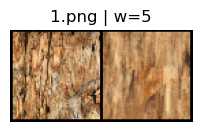

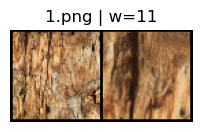

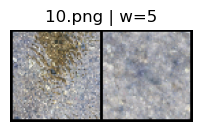

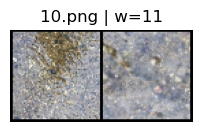

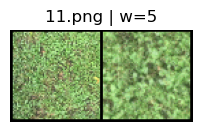

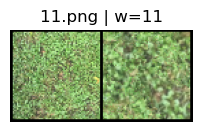

In [ ]:
# ---- Part 1 demo (will run after you implement the TODOs) ----
OUT_H, OUT_W = 64, 64
WINDOWS = [5, 11]          # TODO (tuning): try e.g. [5, 11]
EPS = 0.05            # TODO (tuning): try e.g. 0.02, 0.05, 0.1
MAX_PATCHES = None     # e.g., 50000 to cap candidates for speed/memory
RESIZE_SRC = 192       # resize textures for consistent runtime
NEIGHBORHOOD = 4      # 4 or 8
VERBOSE = False

for path in texture_files[:3]:
    src = load_texture_as_tensor(path, resize=RESIZE_SRC).to(device)
    for w in WINDOWS:
        patches = extract_patches_from_image(src, window=w, max_patches=MAX_PATCHES, device=device)
        out = efros_leung_synthesize_from_patch_pool(
            patches=patches,
            out_h=OUT_H, out_w=OUT_W,
            eps=EPS,
            neighborhood=NEIGHBORHOOD,
            seed_fg_min=0,
            border=0,
            weighted=False,
            h_mult=0.3,
            verbose=VERBOSE,
        )
        show_grid([src.cpu(), out], nrow=2, resize_to=(OUT_H, OUT_W), title=f"{path.name} | w={w}")


## (Required) Tuning / Ablations

This assignment is *not* meant to be one-run-and-done. You should **tune** the key hyperparameters and report what changes.

Minimum tuning expectations (include in the report):
- **Part 1 (textures):** tune `window` size and `eps` (candidate-set threshold).
- **Part 2 (MNIST):** tune `window` size and `eps` (and optionally `seed_fg_min`, `border`, `weighted`).
- **Part 3 (PixelRNN):** tune at least one of: `hidden_dim`, `num_layers`, `dropout`, `lr`, `temperature`.

Below is an optional helper scaffold to run small sweeps. Fill in the TODOs if you want
a clean tuning workflow (recommended).


In [ ]:
from itertools import product

def tune_efros_grid(
    patch_pool_builder,
    window_list,
    eps_list,
    out_h: int,
    out_w: int,
    trials: int = 1,
    synth_kwargs: dict | None = None,
    max_steps: int | None = None,
):
    """
    Grid-search over (window, eps) for Efros–Leung.

    Args:
      patch_pool_builder: function(window:int) -> patches (N,C,window,window) on `device`
      window_list: list of odd window sizes to try, e.g. [5, 11]
      eps_list: list of eps to try, e.g. [0.02, 0.05, 0.1]
      trials: number of random restarts per config (average the score)
      synth_kwargs: extra kwargs passed into efros_leung_synthesize_from_patch_pool
      max_steps: optional cap on fill steps (useful for fast tuning)

    Returns:
      best_cfg: dict with keys {"window", "eps", "score"}
      results: list of dicts (one per config), sorted by ascending score

    TODO:
      - For each (window, eps):
          * build patch pool
          * run efros_leung_synthesize_from_patch_pool(..., return_stats=True, max_steps=max_steps)
          * use stats["avg_dmin"] as a simple score (lower is better)
          * average the score over `trials`
      - Return the best config and a sorted result list.
    """

    results = []
    synth_kwargs = synth_kwargs or {}
    combos = list(product(window_list, eps_list))
    
    for w, e in combos:
        score = 0.0
        patches = patch_pool_builder(window=w)
        for t in range(trials):
            out, stats = efros_leung_synthesize_from_patch_pool(
                patches=patches,
                out_h=OUT_H, 
                out_w=OUT_W,
                eps=e,
                max_steps=max_steps,
                return_stats = True,
                **synth_kwargs
            )
            score += stats["avg_dmin"]
        avg_score = score/trials
        results.append({
            "window":w,
            "eps":e, 
            "score":avg_score
        })
        print(f"Config: w={w}, eps={e} | Avg dmin: {avg_score:.6f}")
    results.sort(key=lambda x: x["score"])
    best_cfg = results[0]
    return best_cfg, results

Config: w=5, eps=0.01 | Avg dmin: 0.024759
Config: w=5, eps=0.02 | Avg dmin: 0.014342
Config: w=5, eps=0.03 | Avg dmin: 0.021594
Config: w=5, eps=0.05 | Avg dmin: 0.018822
Config: w=5, eps=0.1 | Avg dmin: 0.017759
Config: w=5, eps=0.2 | Avg dmin: 0.022566
Config: w=9, eps=0.01 | Avg dmin: 0.216453
Config: w=9, eps=0.02 | Avg dmin: 0.133851
Config: w=9, eps=0.03 | Avg dmin: 0.056744
Config: w=9, eps=0.05 | Avg dmin: 0.186483
Config: w=9, eps=0.1 | Avg dmin: 0.195771
Config: w=9, eps=0.2 | Avg dmin: 0.146090
Config: w=11, eps=0.01 | Avg dmin: 0.213384
Config: w=11, eps=0.02 | Avg dmin: 0.314424
Config: w=11, eps=0.03 | Avg dmin: 0.220269
Config: w=11, eps=0.05 | Avg dmin: 0.296502
Config: w=11, eps=0.1 | Avg dmin: 0.323391
Config: w=11, eps=0.2 | Avg dmin: 0.390158
Config: w=13, eps=0.01 | Avg dmin: 0.339901
Config: w=13, eps=0.02 | Avg dmin: 0.386386
Config: w=13, eps=0.03 | Avg dmin: 0.509958
Config: w=13, eps=0.05 | Avg dmin: 0.595434
Config: w=13, eps=0.1 | Avg dmin: 0.423745
Config:

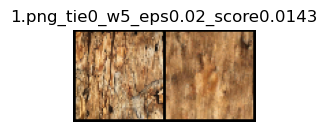

Config: w=5, eps=0.01 | Avg dmin: 0.013273
Config: w=5, eps=0.02 | Avg dmin: 0.014654
Config: w=5, eps=0.03 | Avg dmin: 0.018668
Config: w=5, eps=0.05 | Avg dmin: 0.017886
Config: w=5, eps=0.1 | Avg dmin: 0.023848
Config: w=5, eps=0.2 | Avg dmin: 0.019838
Config: w=9, eps=0.01 | Avg dmin: 0.133013
Config: w=9, eps=0.02 | Avg dmin: 0.082903
Config: w=9, eps=0.03 | Avg dmin: 0.125372
Config: w=9, eps=0.05 | Avg dmin: 0.154988
Config: w=9, eps=0.1 | Avg dmin: 0.117681
Config: w=9, eps=0.2 | Avg dmin: 0.168897
Config: w=11, eps=0.01 | Avg dmin: 0.102391
Config: w=11, eps=0.02 | Avg dmin: 0.291004
Config: w=11, eps=0.03 | Avg dmin: 0.240136
Config: w=11, eps=0.05 | Avg dmin: 0.243657
Config: w=11, eps=0.1 | Avg dmin: 0.260200
Config: w=11, eps=0.2 | Avg dmin: 0.253752
Config: w=13, eps=0.01 | Avg dmin: 0.402310


KeyboardInterrupt: 

In [ ]:
import json
import os
import torch
import matplotlib.pyplot as plt

window_list = [5, 9, 11, 13, 17]
eps_list = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2]
OUT_H, OUT_W = 64, 64
RESIZE_SRC = 192
MAX_PATCHES = 50000 
TRIALS = 10 

synth_settings = {
    "neighborhood": 8,
    "verbose": False,
}

os.makedirs("texture_gen", exist_ok=True)
os.makedirs("texture_results_data", exist_ok=True)

for path in texture_files[:3]:
    src = load_texture_as_tensor(path, resize=RESIZE_SRC).to(device)
    filename = path.name
    
    def my_builder(window):
        return extract_patches_from_image(src, window=window, max_patches=MAX_PATCHES, device=device)

    best_cfg, all_results = tune_efros_grid(
        patch_pool_builder=my_builder,
        window_list=window_list,
        eps_list=eps_list,
        out_h=OUT_H,
        out_w=OUT_W,
        trials=TRIALS,
        synth_kwargs=synth_settings
    )

    image_metadata = {
        "filename": filename,
        "best_config": best_cfg,
        "all_results": all_results
    }
    
    json_path = f"texture_results_data/{filename}_results.json"
    with open(json_path, "w") as f:
        json.dump(image_metadata, f, indent=4)

    min_score = best_cfg['score']
    best_candidates = [res for res in all_results if res['score'] == min_score]
    
    for idx, cfg in enumerate(best_candidates):
        w_val, e_val = cfg['window'], cfg['eps']
        patches_tie = my_builder(w_val)
        
        out_tie, _ = efros_leung_synthesize_from_patch_pool(
            patches=patches_tie, 
            out_h=OUT_H, 
            out_w=OUT_W, 
            eps=e_val, 
            return_stats=True, 
            **synth_settings
        )
        
        title_str = f"{filename}_tie{idx}_w{w_val}_eps{e_val}_score{min_score:.4f}"
        show_grid(
            [src.cpu(), out_tie], 
            nrow=2, 
            resize_to=(OUT_H, OUT_W), 
            folder="texture_gen",
            title=title_str
        )
        plt.show()


In [ ]:
import json
import os
import torch

results_log = []
if os.path.exists("texture_grid_results.json"):
    with open("texture_grid_results.json", "r") as f:
        results_log = json.load(f)

for path in texture_files[:3]:
    src = load_texture_as_tensor(path, resize=RESIZE_SRC).to(device)
    
    def my_builder(window):
        return extract_patches_from_image(src, window=window, max_patches=MAX_PATCHES, device=device)

    print(f"\n>>> Starting Grid Search for: {path.name}")
    
    best_cfg, all_results = tune_efros_grid(
        patch_pool_builder=my_builder,
        window_list=[5, 9, 11, 13, 17],
        eps_list=[0.01, 0.02, 0.03, 0.05, 0.1, 0.2],
        out_h=out_h, out_w=out_w,
        trials=1,
        synth_kwargs=synth_settings
    )

    texture_record = {
        "filename": path.name,
        "best_config": {
            "window": int(best_cfg['window']),
            "eps": float(best_cfg['eps'])
        },
        "detailed_results": [
            {"window": int(r['window']), "eps": float(r['eps']), "score": float(r['score'])} 
            for r in all_results
        ]
    }
    results_log.append(texture_record)

    with open("texture_grid_results.json", "w") as f:
        json.dump(results_log, f, indent=4)

    print(f"Finished {path.name}. Best: w={best_cfg['window']}, eps={best_cfg['eps']}")
    for r in all_results:
        print(f"  Result: w={r['window']}, eps={r['eps']} -> Score: {r['score']:.5f}")

## Part 2 — MNIST (binarized)

MNIST is downloaded automatically.

In [ ]:
def load_binarized_mnist(threshold: float = 0.5):
    transform = T.Compose([T.ToTensor()])
    train_set = torchvision.datasets.MNIST(root="data/", train=True, download=True, transform=transform)
    test_set  = torchvision.datasets.MNIST(root="data/", train=False, download=True, transform=transform)

    x_train = train_set.data.unsqueeze(1).float() / 255.0
    y_train = train_set.targets
    x_test  = test_set.data.unsqueeze(1).float() / 255.0
    y_test  = test_set.targets

    x_train = (x_train > threshold).float()
    x_test  = (x_test  > threshold).float()
    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = load_binarized_mnist(threshold=0.5)
print("MNIST:", x_train.shape, y_train.shape, "unique:", torch.unique(x_train))
print("foreground ratio (mean pixel):", float(x_train.mean().item()))

idx = torch.randperm(x_train.shape[0])[:64]
show_grid([x_train[i,0] for i in idx], nrow=8, title="Binarized MNIST samples", cmap="gray")


patch_pool: torch.Size([50000, 1, 11, 11])


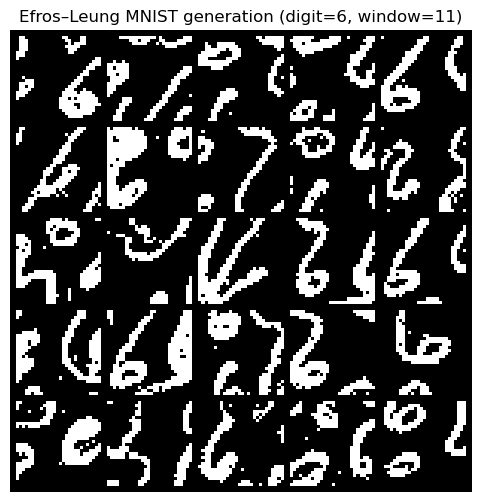

In [ ]:
def extract_patches_from_mnist_batch(
    imgs: torch.Tensor,  # (B,1,28,28) in {0,1}
    window: int,
    max_patches: int,
    device: torch.device = device,
) -> torch.Tensor:
    """Return patches: (N,1,window,window) sampled from the batch."""
    assert imgs.ndim == 4 and imgs.shape[1] == 1
    unfold = torch.nn.Unfold(kernel_size=window, padding=0, stride=1)
    patches = unfold(imgs)  # (B, win*win, L)
    B, D, L = patches.shape
    patches = patches.transpose(1, 2).reshape(B * L, 1, window, window)
    if patches.shape[0] > max_patches:
        idx = torch.randperm(patches.shape[0])[:max_patches]
        patches = patches[idx]
    return patches.to(device)

# ---- Part 2 demo (will run after you implement the TODOs) ----
# TODO (tuning): try different digits and hyperparameters; expect *stroke-like* outputs, not perfect digits.
digit = 6 # Select Your Number
window = 11              # TODO (tuning): e.g. 5, 7, 9
num_source_images = 5000   # TODO (tuning): more sources -> more variety, slower patch pool build
max_patches = 50000       # TODO (tuning): larger -> better coverage, slower matching

# Optional knobs (not required for correctness)
USE_MNIST_HEURISTICS = False  # set True to try a few stability tweaks on MNIST

src_imgs = x_train[y_train == digit]
sel = torch.randperm(src_imgs.shape[0])[:num_source_images]
src_batch = src_imgs[sel].to(device)

patch_pool = extract_patches_from_mnist_batch(src_batch, window=window, max_patches=max_patches, device=device)
print("patch_pool:", patch_pool.shape)

# Core Efros–Leung parameters
eps = 0.01               # TODO (tuning): smaller -> stricter matching, larger -> more randomness
neighborhood = 8          # TODO

# Heuristic parameters (off by default)
seed_fg_min = 0
border = 0
weighted = False
h_mult = 0.3
if USE_MNIST_HEURISTICS:
    seed_fg_min = 4
    border = 2
    weighted = True
    h_mult = 0.25

n_gen = 25
samples = []
for _ in range(n_gen):
    gen = efros_leung_synthesize_from_patch_pool(
        patches=patch_pool, out_h=28, out_w=28,
        eps=eps, neighborhood=neighborhood,
        seed_fg_min=seed_fg_min, border=border,
        weighted=weighted, h_mult=h_mult,
        verbose=False
    )
    samples.append(gen[0])

show_grid(samples, nrow=5, title=f"Efros–Leung MNIST generation (digit={digit}, window={window})", cmap="gray")


In [ ]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import product

window_list = [3, 5, 7, 9, 11, 13]
eps_list = [0.01, 0.05, 0.1]
num_source_images = 1000 
max_patches = 50000       

synth_settings = {
    "neighborhood": 8,
    "seed_fg_min": 4,    
    "border": 2,         
    "weighted": True,    
    "h_mult": 0.25,      
    "verbose": False
}

global_metrics = {}


def mnist_patch_builder(window):
    all_patches = []
    for digit in range(10):
        src_imgs = x_train[y_train == digit]
        sel = torch.randperm(src_imgs.shape[0])[:num_source_images]
        src_batch = src_imgs[sel].to(device)
        
        digit_patches = extract_patches_from_mnist_batch(src_batch, window, max_patches // 10, device)
        all_patches.append(digit_patches)
    
    return torch.cat(all_patches, dim=0)

best_cfg, all_results = tune_efros_grid(
    patch_pool_builder=mnist_patch_builder,
    window_list=window_list,
    eps_list=eps_list,
    out_h=28,
    out_w=28,
    trials=10, 
    synth_kwargs=synth_settings
)

for res in all_results:
    w = res['window']
    e = res['eps']
    avg_score = res['score']
    
    config_samples = []
    config_scores = []
    
    for digit in range(10):
        src_imgs = x_train[y_train == digit]
        sel = torch.randperm(src_imgs.shape[0])[:num_source_images]
        src_batch = src_imgs[sel].to(device)
        
        patches = extract_patches_from_mnist_batch(src_batch, w, max_patches, device)
        
        gen, stats = efros_leung_synthesize_from_patch_pool(
            patches=patches, out_h=28, out_w=28, eps=e, return_stats=True, **synth_settings
        )
        
        config_samples.append(gen[0])
        config_scores.append(stats['avg_dmin'])
    
    title = f"global_w{w}_eps{e}"
    show_grid(config_samples, nrow=5, folder="mnist_search", 
              title=f"{title} | Avg Score: {avg_score:.4f}", cmap="gray")
    plt.show()
    
    global_metrics[f"({w}, {e})"] = {
        "window": w,
        "eps": e,
        "avg_score": avg_score,
        "image_path": f"mnist_search/{title}.png",
        "digit_scores": config_scores
    }

with open("mnist_grid.json", "w") as f:
    json.dump(global_metrics, f, indent=4)

## Part 3 — PixelRNN (binarized MNIST)

Implement a raster-scan autoregressive RNN.

In [ ]:
def make_pixel_sequences(x: torch.Tensor):
    """
    x: (B,1,28,28) in {0,1}
    Returns:
      x_in: (B,784) tokens in {0,1,2} where 2 is START
      y:    (B,784) float targets in {0,1}
    """
    B = x.shape[0]
    pixels = x.view(B, -1).long()
    start = torch.full((B, 1), 2, dtype=torch.long)
    x_in = torch.cat([start, pixels[:, :-1]], dim=1)
    y = pixels.float()
    return x_in, y

def make_dataloaders(x_train, x_test, batch_size=128, train_subset=None):
    if train_subset is not None and train_subset < x_train.shape[0]:
        idx = torch.randperm(x_train.shape[0])[:train_subset]
        x_tr = x_train[idx]
    else:
        x_tr = x_train

    x_in_tr, y_tr = make_pixel_sequences(x_tr)
    x_in_te, y_te = make_pixel_sequences(x_test)

    train_ds = TensorDataset(x_in_tr, y_tr)
    test_ds = TensorDataset(x_in_te, y_te)

    num_workers = 2 if device.type == "cuda" else 0
    pin_memory = (device.type == "cuda")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers,
                              pin_memory=pin_memory, persistent_workers=(num_workers > 0))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers,
                             pin_memory=pin_memory, persistent_workers=(num_workers > 0))
    return train_loader, test_loader


In [ ]:
class PixelRNN(nn.Module):
    def __init__(self, emb_dim=32, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()

        # DONE:
        #   - token embedding: nn.Embedding(3, emb_dim)
        #   - row/col embeddings: nn.Embedding(28, emb_dim) each
        #   - LSTM: nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True, ...)
        #   - output head: nn.Linear(hidden_dim, 1) to produce logits for x_t
        #
        # IMPORTANT: this must be a *causal* model. Do NOT peek at future pixels.
        
        self.emb = nn.Embedding(3, emb_dim) # Tokens: 0, 1, START. (Use START = 2)

        # Positions: row index in [0..27], col index in [0..27]
        self.row_emb = nn.Embedding(28, emb_dim)
        self.col_emb = nn.Embedding(28, emb_dim)


        #(N, L, Hin)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        #bidirectional=False by default, 
        self.out = nn.Linear(hidden_dim, 1) #produce logits

        # Optional convenience (recommended): precompute raster positions for length 784 (T=28*28)
        t = torch.arange(28 * 28)
        self.register_buffer("pos_row", (t // 28).long(), persistent=False)
        self.register_buffer("pos_col", (t % 28).long(), persistent=False)


    def forward(self, x_in: torch.Tensor):
        """
        x_in: (B,784) tokens in {0,1,2}, where 2 denotes START at t=0 (teacher-forcing input).
        Return:
          logits: (B,784) where logits[:,t] parameterizes p(x_t=1 | x_<t)

        Notes:
          - `make_pixel_sequences()` already inserts the START token and shifts the sequence.
          - Add row/col positional embeddings based on t -> (t//28, t%28).
        """
        self_feat = self.emb(x_in) # (B, 784, emb_dim)
        row_feat = self.row_emb(self.pos_row).unsqueeze(0) #(1, 784, emb_dim)
        col_feat = self.col_emb(self.pos_col).unsqueeze(0) #(1, 784, emb_dim)

        total_in = self_feat + row_feat + col_feat #(B, 784, emb_dim) -> broadcast
        
        output, _ = self.lstm(total_in) #(B, 784, hidden_dim)
        return self.out(output).squeeze(-1) #(B, 784)

    
    @torch.no_grad()
    def sample(self, n: int, temperature: float = 1.0):
        """
        Ancestral sampling in raster order.
        Return: samples (n,1,28,28) in {0,1}.

        TODO:
          - Start with prev token = START for all n samples.
          - For t=0..783:
              - embed prev token (+ positional embedding for position t)
              - run 1-step LSTM using cached hidden state
              - map hidden -> logit -> prob
              - sample next pixel using Bernoulli(prob)
              - set prev = sampled pixel token (0/1)
        """
        prev = 2 #start
        device = next(self.parameters()).device

        samples = torch.zeros((n, 28 * 28), dtype=torch.long, device=device)
        prev = torch.full((n, 1), 2, dtype=torch.long, device=device)
        states = None
        
        for t in range(784):
            token_emb = self.emb(prev) #(n, 1, emb_dim)

            #(1, 1, emb_dim)
            row_emb = self.row_emb(self.pos_row[t]).view(1, 1, -1)
            col_emb = self.col_emb(self.pos_col[t]).view(1, 1, -1)
            
            x_t = token_emb + row_emb + col_emb #(n, 1, emb_dim) -> broadcast
            
            output, states = self.lstm(x_t, states)#(N, 1, Hin) => (N, 1, hidden)
            logit = self.out(output).squeeze(-1) # hidden to 1 out per batch/pixel -> (N, 1)
            prob = torch.sigmoid(logit / temperature)
            
            pixel_sample = torch.bernoulli(prob).long() 
            samples[:, t] = pixel_sample.squeeze(-1)
            prev = pixel_sample
            
        return samples.view(n, 1, 28, 28) * 255

In [ ]:
def evaluate_nll_per_pixel(model: nn.Module, loader: DataLoader):
    model.eval()
    total = 0.0
    count = 0
    bce = nn.BCEWithLogitsLoss(reduction="sum")
    with torch.no_grad():
        for x_in, y in loader:
            x_in = x_in.to(device)
            y = y.to(device)
            logits = model(x_in)
            loss = bce(logits, y)
            total += float(loss.item())
            count += int(y.numel())
    return total / count

def train_pixelrnn(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss(reduction="mean")
    history = {"train_loss": [], "test_nll": []}

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        n_batches = 0
        pbar = tqdm(train_loader, desc=f"epoch {ep}/{epochs}")
        for x_in, y in pbar:
            x_in = x_in.to(device)
            y = y.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(x_in)
            loss = bce(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=running / n_batches)

        train_loss = running / max(1, n_batches)
        test_nll = evaluate_nll_per_pixel(model, test_loader)
        history["train_loss"].append(train_loss)
        history["test_nll"].append(test_nll)
        print(f"epoch {ep}: train_loss={train_loss:.4f} | test_nll/pixel={test_nll:.4f}")

    return history


### PixelRNN tuning helper (optional but recommended)

A simple hyperparameter sweep runner. Use a small `train_subset` and few epochs so you can iterate quickly.
Then train your best configuration longer for the final results.


Starting sweep on device: cuda

--- Running Config 1/11 ---
Args: {'emb_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.1}, LR: 0.001


epoch 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2412 | test_nll/pixel=0.1645


epoch 2/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1457 | test_nll/pixel=0.1270


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0391526170>
Traceback (most recent call last):
  File "/home/angela/miniconda3/envs/ML/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/angela/miniconda3/envs/ML/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/angela/miniconda3/envs/ML/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0391526170>
Traceback (most recent call last):
  File "/home/angela/miniconda3/envs/ML/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/angela/miniconda3/envs/ML/lib/python3.10/site-p

Model saved to config_1_emb32_hid256_L2_lr0.001.pt
Results for Config 1: Test NLL = 0.1270


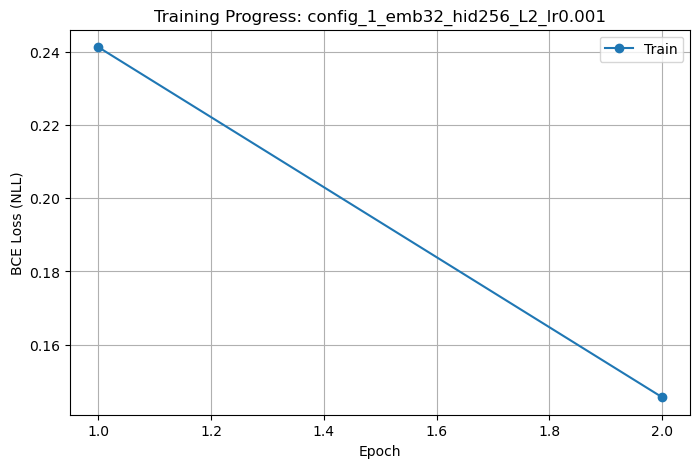

Generating samples...


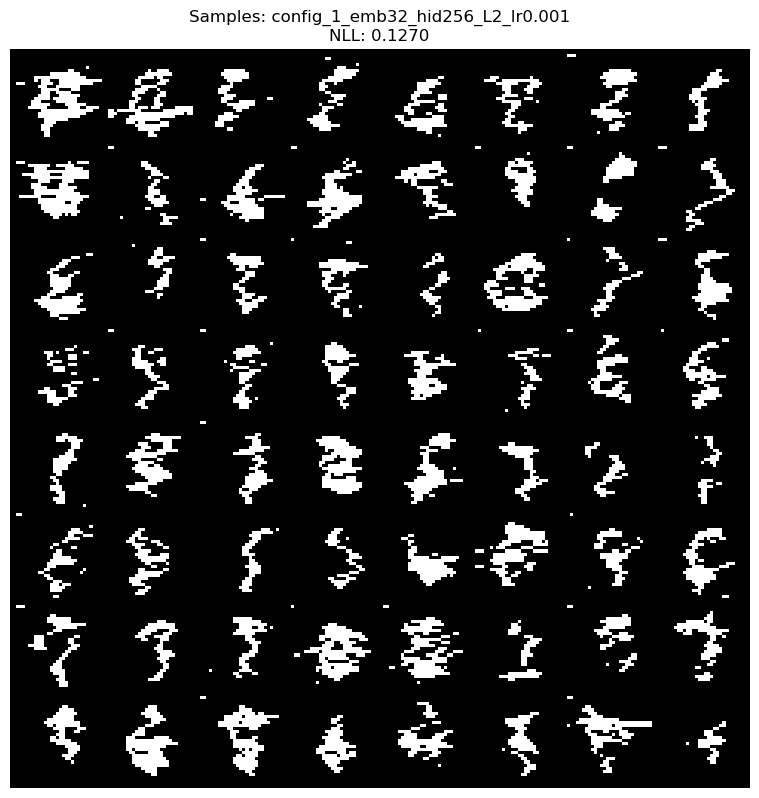

<Figure size 640x480 with 0 Axes>


--- Running Config 2/11 ---
Args: {'emb_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'dropout': 0.2}, LR: 0.001


epoch 1/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.3103 | test_nll/pixel=0.1745


epoch 2/5:   0%|          | 0/79 [00:00<?, ?it/s]

...

epoch 3: train_loss=0.1285 | test_nll/pixel=0.1144


epoch 4/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 4: train_loss=0.1120 | test_nll/pixel=0.1049


epoch 5/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 5: train_loss=0.1042 | test_nll/pixel=0.0975
Model saved to config_2_emb32_hid256_L4_lr0.001.pt
Results for Config 2: Test NLL = 0.0975


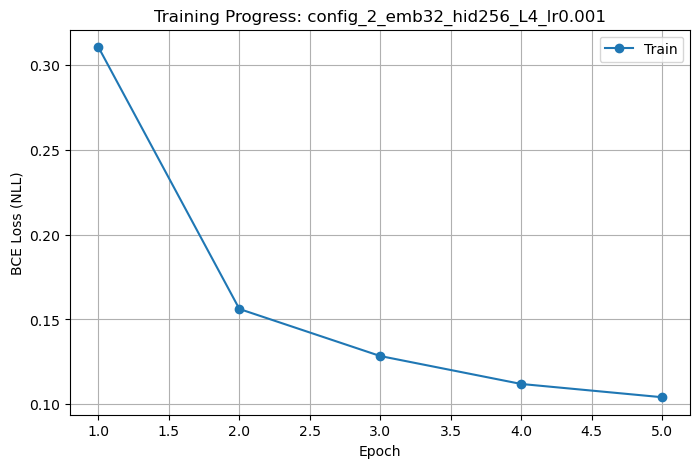

Generating samples...


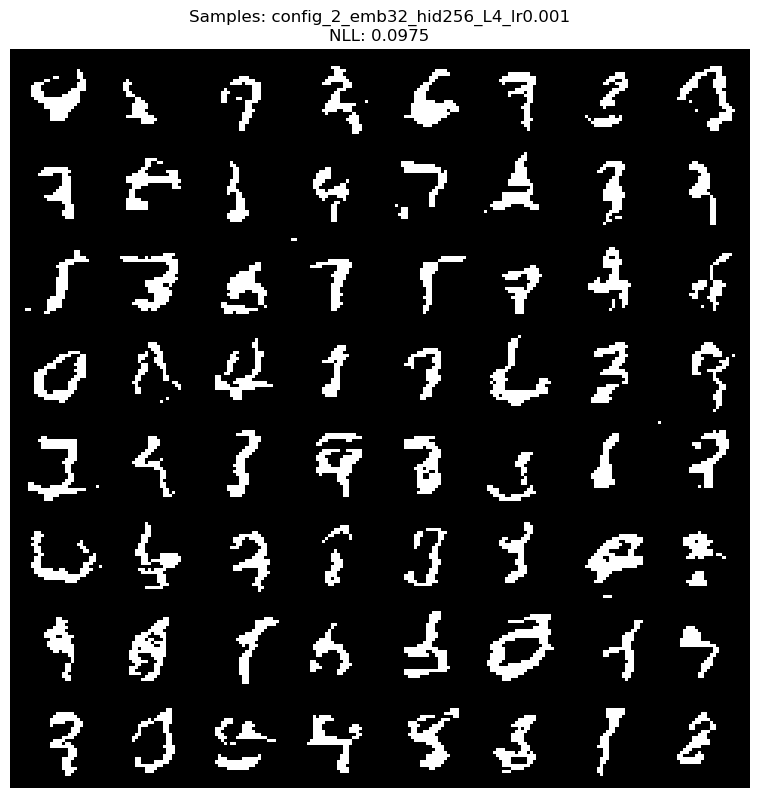

<Figure size 640x480 with 0 Axes>


--- Running Config 3/11 ---
Args: {'emb_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.1}, LR: 0.01


epoch 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2077 | test_nll/pixel=0.1641


epoch 2/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1476 | test_nll/pixel=0.1227
Model saved to config_3_emb32_hid256_L2_lr0.01.pt
Results for Config 3: Test NLL = 0.1227


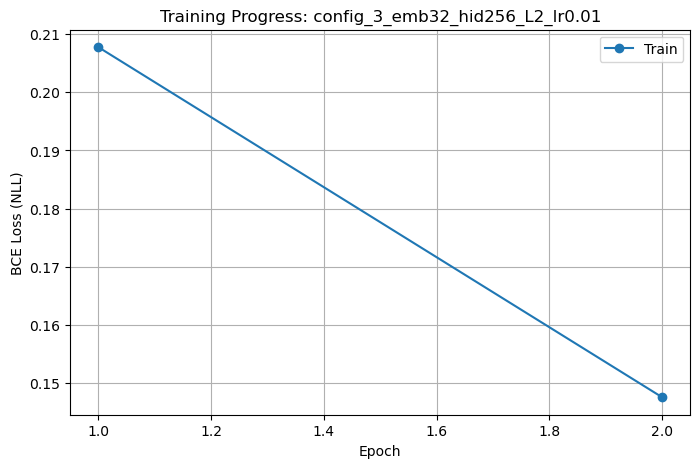

Generating samples...


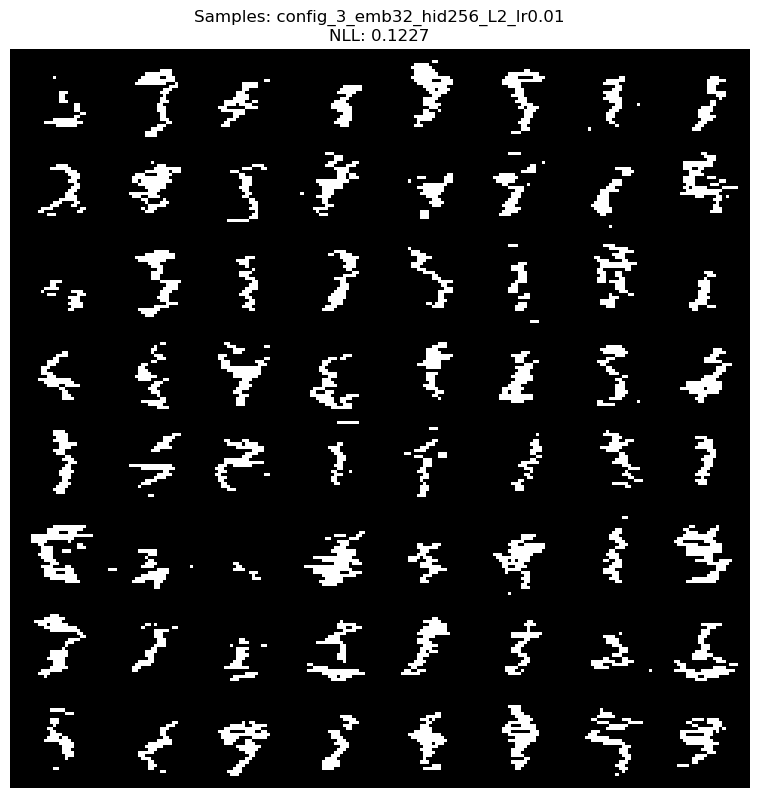

<Figure size 640x480 with 0 Axes>


--- Running Config 4/11 ---
Args: {'emb_dim': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.1}, LR: 0.001


epoch 1/3:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2134 | test_nll/pixel=0.1613


epoch 2/3:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1465 | test_nll/pixel=0.1290


epoch 3/3:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 3: train_loss=0.1212 | test_nll/pixel=0.1117
Model saved to config_4_emb128_hid256_L2_lr0.001.pt
Results for Config 4: Test NLL = 0.1117


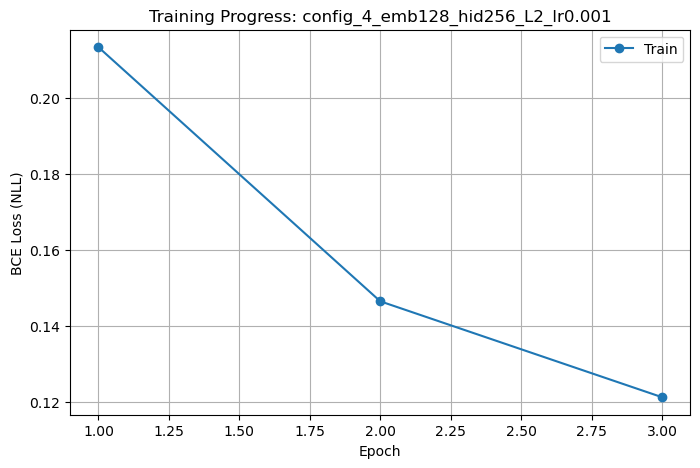

Generating samples...


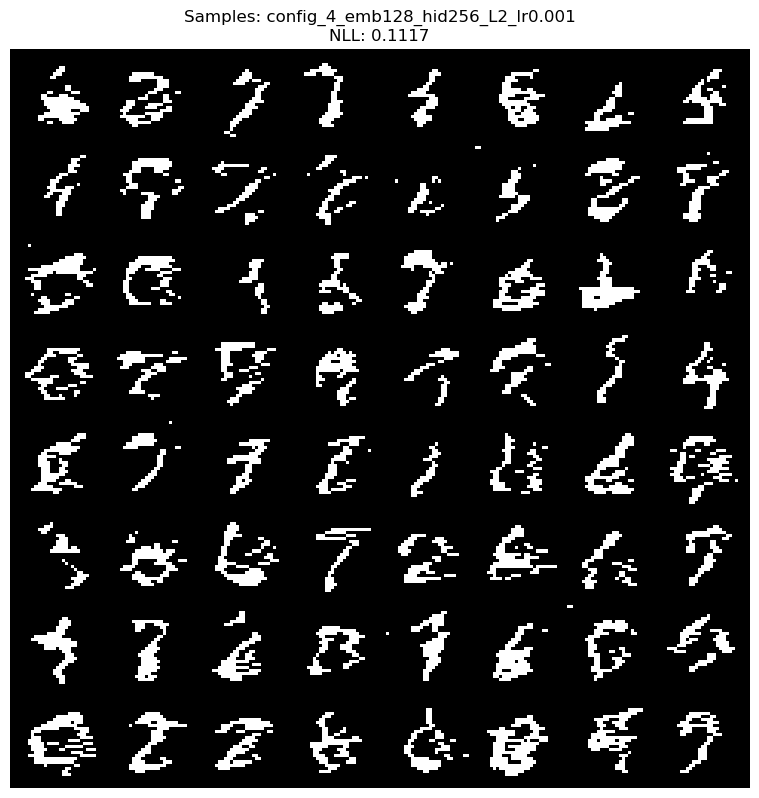

<Figure size 640x480 with 0 Axes>


--- Running Config 5/11 ---
Args: {'emb_dim': 16, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.0}, LR: 0.001


epoch 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2924 | test_nll/pixel=0.1778


epoch 2/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1621 | test_nll/pixel=0.1479
Model saved to config_5_emb16_hid128_L2_lr0.001.pt
Results for Config 5: Test NLL = 0.1479


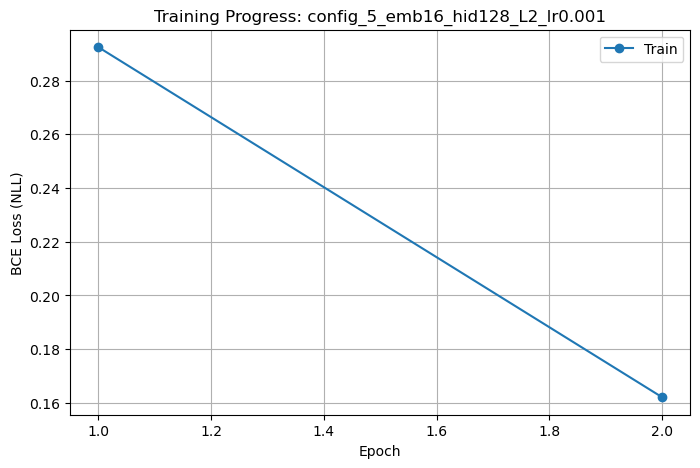

Generating samples...


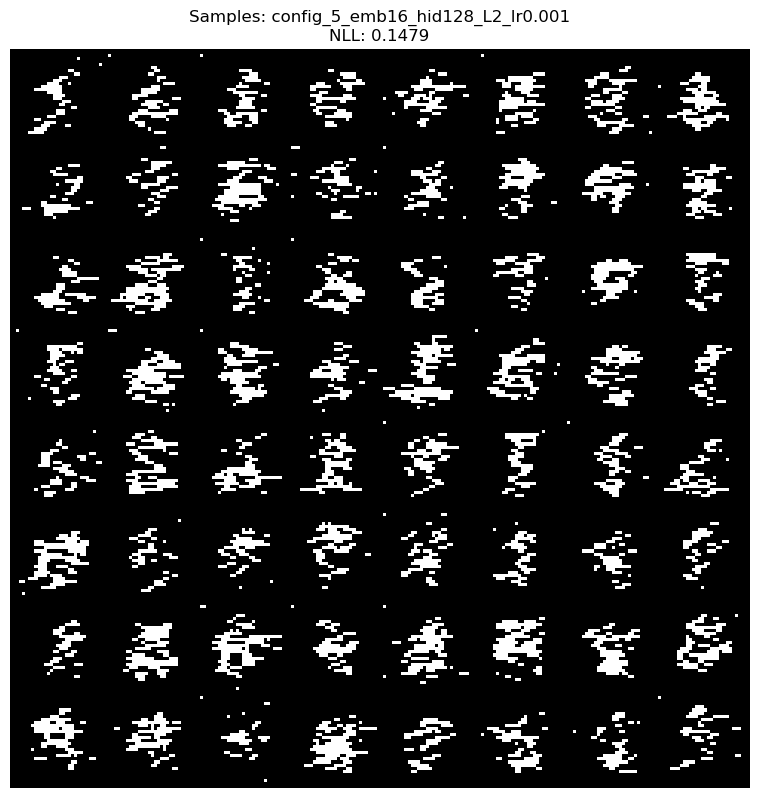

<Figure size 640x480 with 0 Axes>


--- Running Config 6/11 ---
Args: {'emb_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.1}, LR: 0.001


epoch 1/10:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2266 | test_nll/pixel=0.1620


epoch 2/10:   0%|          | 0/79 [00:00<?, ?it/s]

...

epoch 8: train_loss=0.0896 | test_nll/pixel=0.0891


epoch 9/10:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 9: train_loss=0.0881 | test_nll/pixel=0.0867


epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 10: train_loss=0.0870 | test_nll/pixel=0.0862
Model saved to config_6_emb64_hid256_L2_lr0.001.pt
Results for Config 6: Test NLL = 0.0862


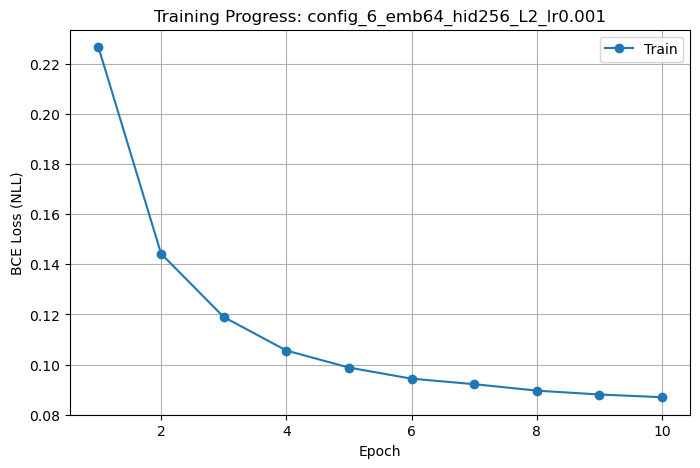

Generating samples...


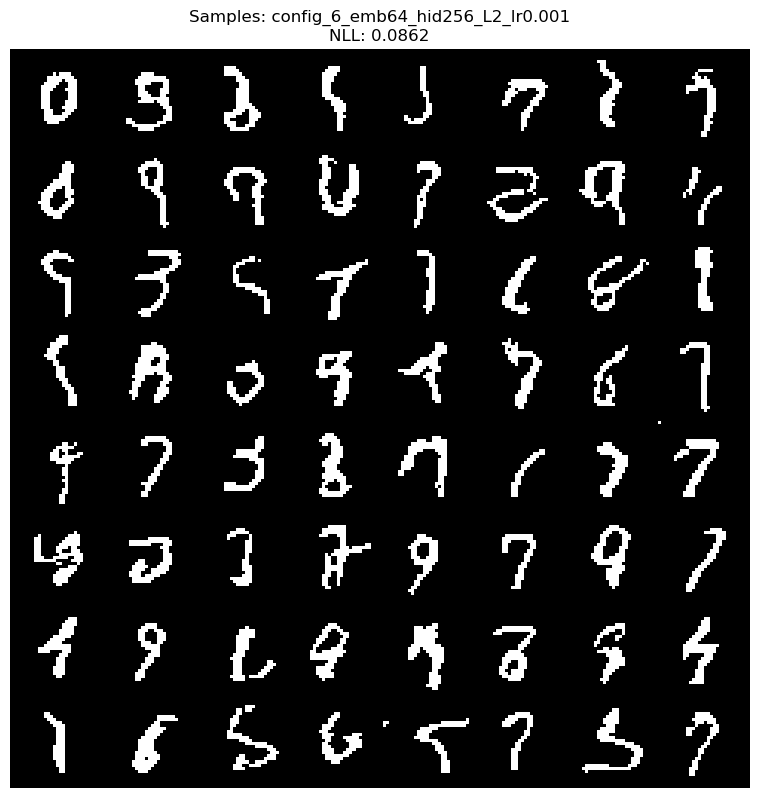

<Figure size 640x480 with 0 Axes>


--- Running Config 7/11 ---
Args: {'emb_dim': 64, 'hidden_dim': 512, 'num_layers': 3, 'dropout': 0.2}, LR: 0.0005


epoch 1/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2463 | test_nll/pixel=0.1620


epoch 2/5:   0%|          | 0/79 [00:00<?, ?it/s]

...

epoch 3: train_loss=0.1192 | test_nll/pixel=0.1070


epoch 4/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 4: train_loss=0.1030 | test_nll/pixel=0.0965


epoch 5/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 5: train_loss=0.0952 | test_nll/pixel=0.0926
Model saved to config_7_emb64_hid512_L3_lr0.0005.pt
Results for Config 7: Test NLL = 0.0926


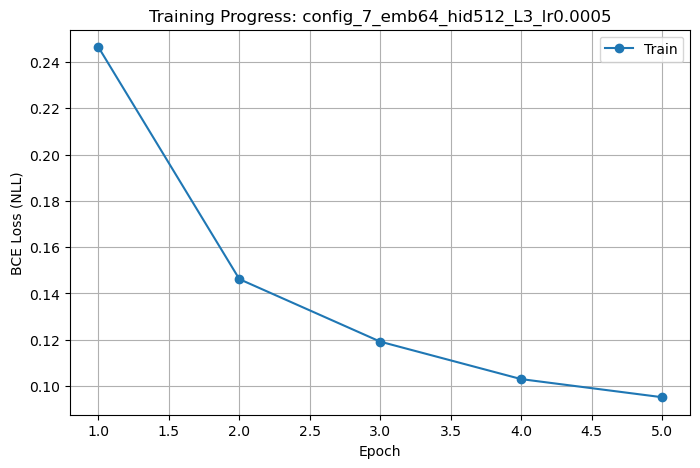

Generating samples...


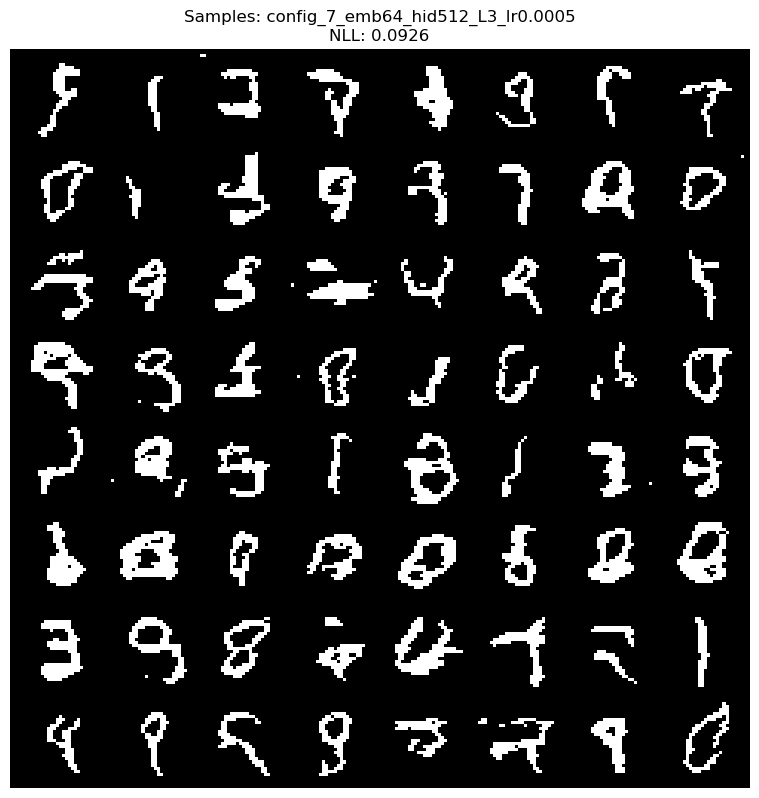

<Figure size 640x480 with 0 Axes>


--- Running Config 8/11 ---
Args: {'emb_dim': 256, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.1}, LR: 0.001


epoch 1/3:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2378 | test_nll/pixel=0.1655


epoch 2/3:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1569 | test_nll/pixel=0.1446


epoch 3/3:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 3: train_loss=0.1333 | test_nll/pixel=0.1205
Model saved to config_8_emb256_hid128_L2_lr0.001.pt
Results for Config 8: Test NLL = 0.1205


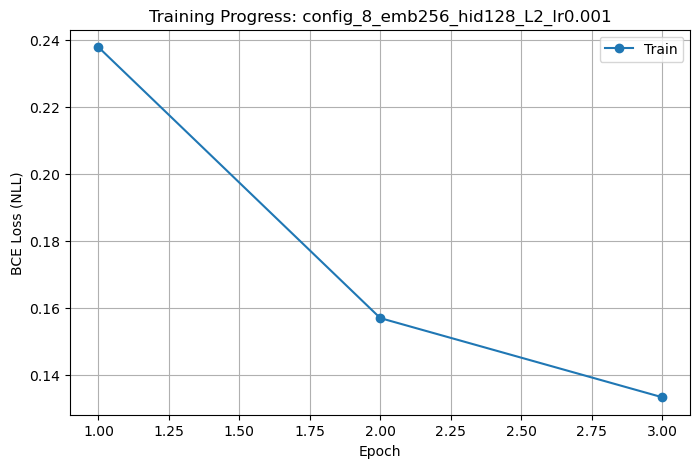

Generating samples...


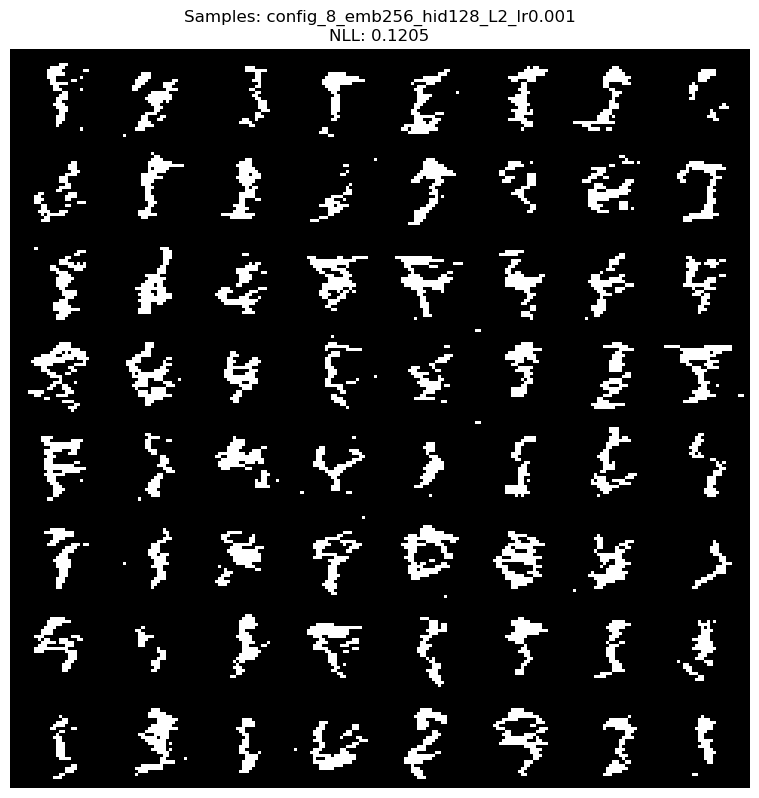

<Figure size 640x480 with 0 Axes>


--- Running Config 9/11 ---
Args: {'emb_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.0}, LR: 0.001


epoch 1/15:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2274 | test_nll/pixel=0.1624


epoch 2/15:   0%|          | 0/79 [00:00<?, ?it/s]

...

epoch 13: train_loss=0.0821 | test_nll/pixel=0.0839


epoch 14/15:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 14: train_loss=0.0814 | test_nll/pixel=0.0821


epoch 15/15:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 15: train_loss=0.0803 | test_nll/pixel=0.0811
Model saved to config_9_emb64_hid256_L2_lr0.001.pt
Results for Config 9: Test NLL = 0.0811


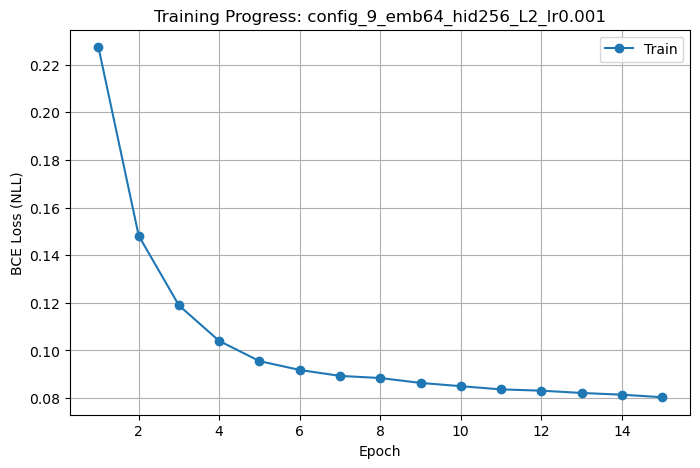

Generating samples...


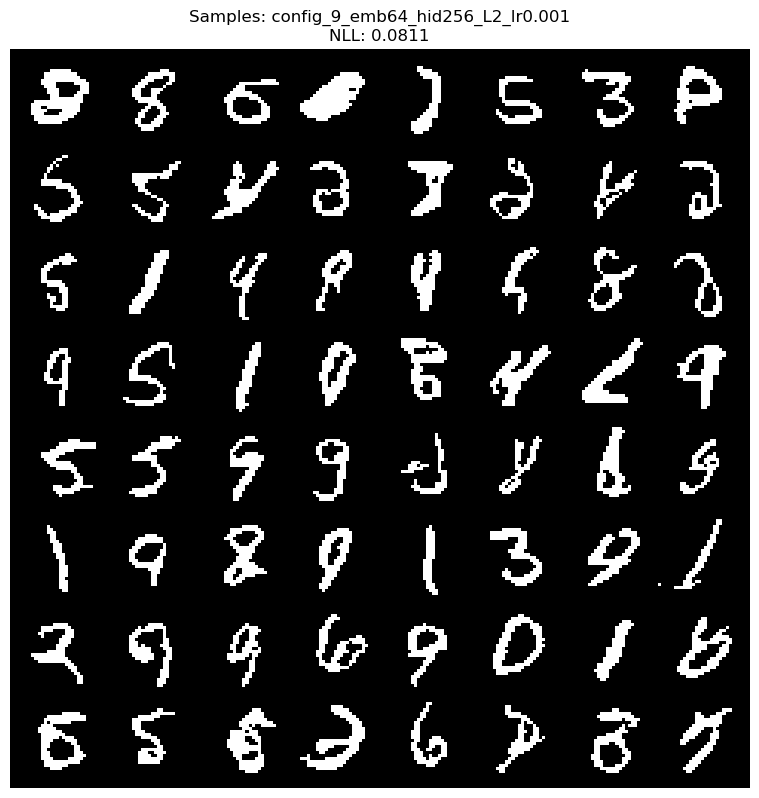

<Figure size 640x480 with 0 Axes>


--- Running Config 10/11 ---
Args: {'emb_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.1}, LR: 0.0001


epoch 1/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.4375 | test_nll/pixel=0.3209


epoch 2/5:   0%|          | 0/79 [00:00<?, ?it/s]

...

epoch 3: train_loss=0.1886 | test_nll/pixel=0.1646


epoch 4/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 4: train_loss=0.1567 | test_nll/pixel=0.1457


epoch 5/5:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 5: train_loss=0.1416 | test_nll/pixel=0.1349
Model saved to config_10_emb32_hid256_L2_lr0.0001.pt
Results for Config 10: Test NLL = 0.1349


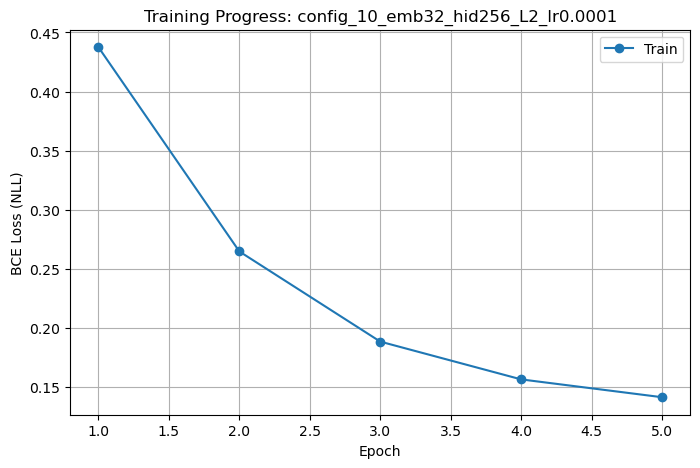

Generating samples...


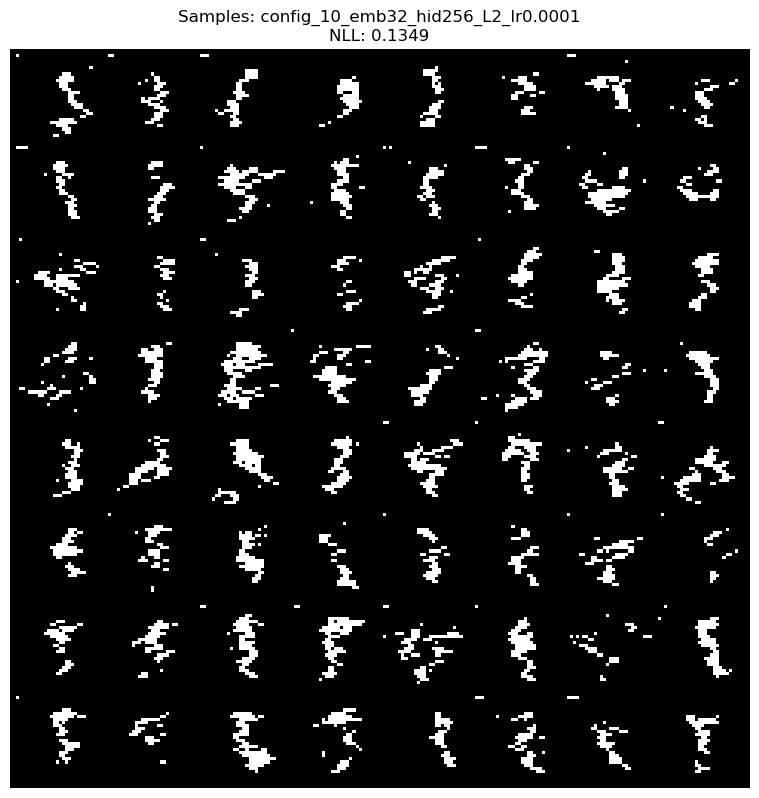

<Figure size 640x480 with 0 Axes>


--- Running Config 11/11 ---
Args: {'emb_dim': 4, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.1}, LR: 0.001


epoch 1/4:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.3327 | test_nll/pixel=0.2324


epoch 2/4:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1919 | test_nll/pixel=0.1637


epoch 3/4:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 3: train_loss=0.1498 | test_nll/pixel=0.1286


epoch 4/4:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 4: train_loss=0.1182 | test_nll/pixel=0.1062
Model saved to config_11_emb4_hid512_L2_lr0.001.pt
Results for Config 11: Test NLL = 0.1062


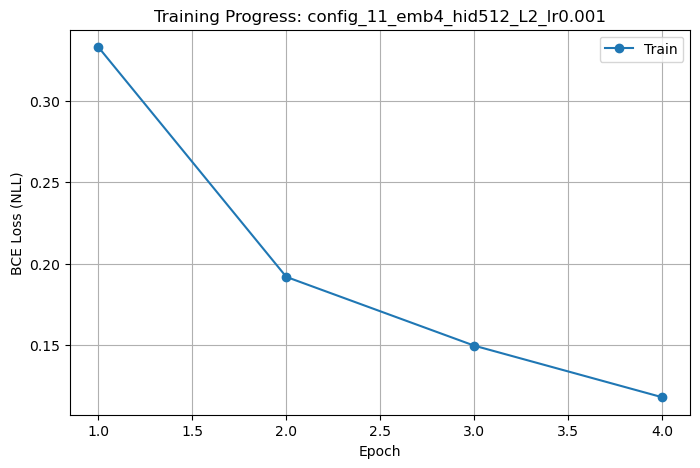

Generating samples...


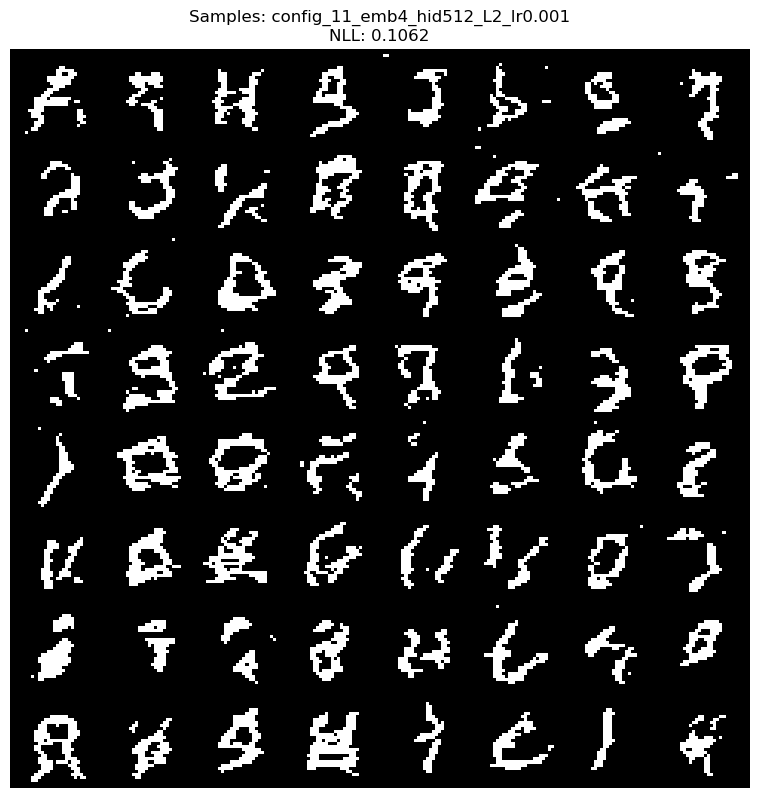

<Figure size 640x480 with 0 Axes>

[{'config': {'model_kwargs': {'emb_dim': 64,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.0},
   'lr': 0.001,
   'epochs': 15},
  'test_nll': 0.08114434526404556},
 {'config': {'model_kwargs': {'emb_dim': 64,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.1},
   'lr': 0.001,
   'epochs': 10},
  'test_nll': 0.08616043059679927},
 {'config': {'model_kwargs': {'emb_dim': 64,
    'hidden_dim': 512,
    'num_layers': 3,
    'dropout': 0.2},
   'lr': 0.0005,
   'epochs': 5},
  'test_nll': 0.09258427362247389},
 {'config': {'model_kwargs': {'emb_dim': 32,
    'hidden_dim': 256,
    'num_layers': 4,
    'dropout': 0.2},
   'lr': 0.001,
   'epochs': 5},
  'test_nll': 0.09747944919819734},
 {'config': {'model_kwargs': {'emb_dim': 4,
    'hidden_dim': 512,
    'num_layers': 2,
    'dropout': 0.1},
   'lr': 0.001,
   'epochs': 4},
  'test_nll': 0.10619065176516163},
 {'config': {'model_kwargs': {'emb_dim': 128,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout'

In [ ]:
import json


def sweep_pixelrnn_configs(
    x_train: torch.Tensor,
    x_test: torch.Tensor,
    configs: list[dict],
    train_subset: int = 10000,
    epochs: int = 2,
    batch_size: int = 128,
):
    """
    Sweep a list of PixelRNN configs.

    Each entry in `configs` is a dict like:
      {
        "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1},
        "lr": 1e-3,
      }

    TODO:
      - For each config:
          * make loaders with make_dataloaders(..., train_subset=train_subset)
          * instantiate PixelRNN(**model_kwargs)
          * train with train_pixelrnn(..., epochs=epochs, lr=lr)
          * evaluate test_nll_per_pixel via evaluate_nll_per_pixel
      - Return a list of results sorted by test_nll (ascending)
    """
    results = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting sweep on device: {device}")

    for i, config in enumerate(configs):
        model_kwargs = config.get("model_kwargs", {})
        lr = config.get("lr", 1e-3)
        config_name = f"config_{i+1}_emb{model_kwargs['emb_dim']}_hid{model_kwargs['hidden_dim']}_L{model_kwargs['num_layers']}_lr{lr}"
        if os.path.exists("sweep_results.json"):
            with open("sweep_results.json", "r") as f:
                results = json.load(f)
        model_path = f"{config_name}.pt"
        

        print(f"\n--- Running Config {i+1}/{len(configs)} ---")
        print(f"Args: {model_kwargs}, LR: {lr}")

        train_loader, test_loader = make_dataloaders(
            x_train, x_test, batch_size=batch_size, train_subset=train_subset
        )
        model = PixelRNN(**model_kwargs).to(device)
        current_epochs = config.get("epochs", epochs)
        history = train_pixelrnn(model, train_loader, test_loader, epochs=current_epochs, lr=lr)
        test_nll = evaluate_nll_per_pixel(model, test_loader)
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")
        
        print(f"Results for Config {i+1}: Test NLL = {test_nll:.4f}")
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o", label="Train")
        if "test_loss" in history:
            plt.plot(range(1, len(history["test_loss"]) + 1), history["test_loss"], marker="s", label="Test")
        plt.xlabel("Epoch")
        plt.ylabel("BCE Loss (NLL)")
        plt.title(f"Training Progress: {config_name}")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{config_name}_loss.png")
        plt.show()

        print("Generating samples...")
        model.eval()
        samples = model.sample(n=64) 
        
        show_grid(
            [samples[i, 0] for i in range(64)], 
            nrow=8, 
            title=f"Samples: {config_name}\nNLL: {test_nll:.4f}", 
            cmap="gray"
        )
        plt.savefig(f"{config_name}_samples.png")
        plt.show()
        
        # Store results
        results.append({
            "config": config,
            "test_nll": test_nll
        })

        with open("sweep_results.json", "w") as f:
            json.dump(results, f, indent=4)


        del model
        torch.cuda.empty_cache()

    results.sort(key=lambda x: x["test_nll"])

    return results

configs_to_test = [
    { 
        "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-3, 
        "epochs": 2 
    },
    { 
        "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 4, "dropout": 0.2}, 
        "lr": 1e-3, 
        "epochs": 5 
    },
    { 
        "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-2, 
        "epochs": 2 
    },
    { 
        "model_kwargs": {"emb_dim": 128, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-3, 
        "epochs": 3 
    },
    { 
        "model_kwargs": {"emb_dim": 16, "hidden_dim": 128, "num_layers": 2, "dropout": 0.0}, 
        "lr": 1e-3, 
        "epochs": 2 
    },
    { 
        "model_kwargs": {"emb_dim": 64, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-3, 
        "epochs": 10 
    },
    { 
        "model_kwargs": {"emb_dim": 64, "hidden_dim": 512, "num_layers": 3, "dropout": 0.2}, 
        "lr": 5e-4,
        "epochs": 5 
    },
    { 
        "model_kwargs": {"emb_dim": 256, "hidden_dim": 128, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-3, 
        "epochs": 3 
    },
    { 
        "model_kwargs": {"emb_dim": 64, "hidden_dim": 256, "num_layers": 2, "dropout": 0.0}, 
        "lr": 1e-3, 
        "epochs": 15 
    },
    { 
        "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-4, 
        "epochs": 5 
    },
    { 
        "model_kwargs": {"emb_dim": 4, "hidden_dim": 512, "num_layers": 2, "dropout": 0.1}, 
        "lr": 1e-3, 
        "epochs": 4 
    },
]

sweep_pixelrnn_configs(
    x_train, x_test, configs_to_test
)

epoch 1/10:   0%|          | 0/938 [00:00<?, ?it/s]

epoch 1: train_loss=0.1125 | test_nll/pixel=0.0871


epoch 2/10:   0%|          | 0/938 [00:00<?, ?it/s]

epoch 2: train_loss=0.0827 | test_nll/pixel=0.0796


epoch 3/10:   0%|          | 0/938 [00:00<?, ?it/s]

...

epoch 8: train_loss=0.0728 | test_nll/pixel=0.0729


epoch 9/10:   0%|          | 0/938 [00:00<?, ?it/s]

epoch 9: train_loss=0.0722 | test_nll/pixel=0.0723


epoch 10/10:   0%|          | 0/938 [00:00<?, ?it/s]

epoch 10: train_loss=0.0716 | test_nll/pixel=0.0718


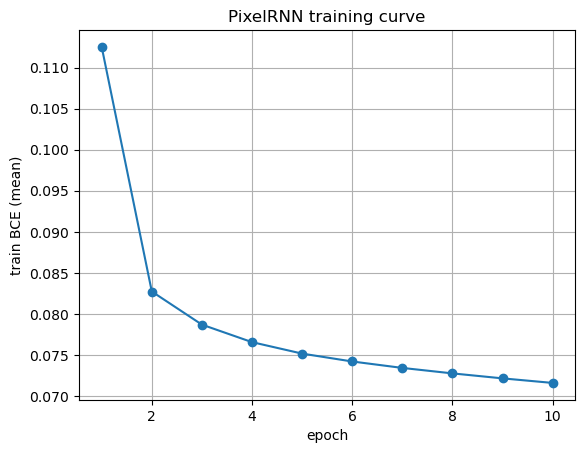

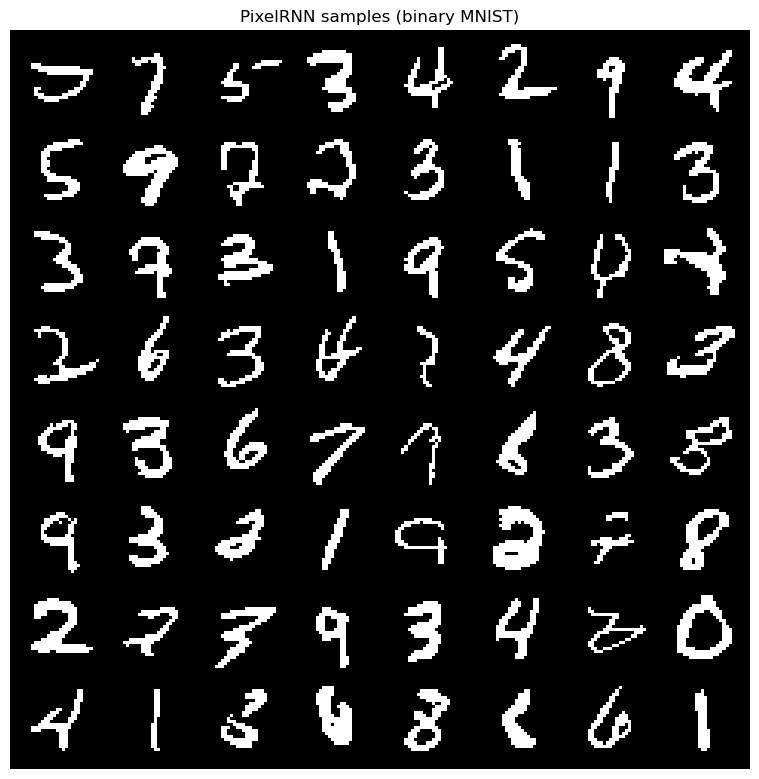

In [ ]:
# ---- Part 3 demo (will run after you implement PixelRNN) ----
# TODO (tuning): change model size and training hyperparameters; report test NLL/pixel + sample quality.
BATCH_SIZE = 64
TRAIN_SUBSET = None   # e.g., 10000 for quick debugging / sweeps
EPOCHS = 10
LR =  1e-3# e.g.,1e-3

MODEL_KWARGS = dict(
    emb_dim= 64,        # TODO (tuning)
    hidden_dim= 256,    # TODO (tuning)
    num_layers= 2,      # TODO (tuning)
    dropout=0.1,
)

TEMPERATURE = 1.0     # TODO (tuning)e.g.,0.7～1.3

train_loader, test_loader = make_dataloaders(
    x_train, x_test,
    batch_size=BATCH_SIZE,
    train_subset=TRAIN_SUBSET,
)

model = PixelRNN(**MODEL_KWARGS).to(device)
history = train_pixelrnn(model, train_loader, test_loader, epochs=EPOCHS, lr=LR)

plt.figure()
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("train BCE (mean)")
plt.title("PixelRNN training curve")
plt.grid(True)
plt.show()

samples = model.sample(n=64, temperature=TEMPERATURE)
show_grid([samples[i, 0] for i in range(64)], nrow=8, title="PixelRNN samples (binary MNIST)", cmap="gray")
